<a href="https://colab.research.google.com/github/KeitaYami/CDNC-PhanTichDuLieu/blob/main/CDNC_PHAN_TICH_DU_LIEU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Phân tích rủi ro vỡ nợ và ước lượng tổn thất tín dụng — Phiên bản 2

Notebook này được thiết kế để tạo ra **bảng và biểu đồ có thể đưa trực tiếp vào báo cáo PDF**. Quy trình gồm bốn lớp phân tích:

1. **Data profiling và EDA:** mô tả chất lượng dữ liệu, mất cân bằng lớp, nhân khẩu học và hành vi tín dụng.
2. **Probability of Default (PD):** so sánh mô hình nền, Logistic Regression và Random Forest.
3. **Exposure at Default proxy (EAD):** dự báo dư nợ dương của kỳ gần nhất từ các kỳ lịch sử trước đó.
4. **Expected Loss minh họa:** kết hợp `PD × EAD × LGD` theo ba kịch bản tổn thất.

> **Lưu ý học thuật:** đây là khung phân tích minh họa trên dữ liệu công khai. `BILL_AMT1` chỉ được dùng như một **đại diện gần đúng cho EAD**, còn LGD là giả định kịch bản, không phải tổn thất thực tế hay mô hình ECL theo chuẩn quản trị ngân hàng.

Tất cả bảng CSV và hình PNG độ phân giải cao sẽ được lưu trong thư mục `cdnc_outputs` và đóng gói thành file ZIP ở cuối notebook.


> Phiên bản 2 bổ sung hiệu chỉnh xác suất PD (probability calibration) và kiểm tra tính hợp lý của Expected Loss trước khi đưa vào báo cáo.

In [23]:

# Cài thư viện tải dữ liệu trên Google Colab
!pip -q install kagglehub


In [24]:

import os
import glob
import json
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from matplotlib.ticker import PercentFormatter

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    brier_score_loss,
    log_loss,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_validate,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
OUTPUT_DIR = (
    "/content/cdnc_outputs"
    if os.path.exists("/content")
    else os.path.abspath("cdnc_outputs")
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
PRIMARY_COLOR = sns.color_palette("deep")[0]
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def savefig(filename: str) -> None:
    """Lưu hình hiện tại ở độ phân giải phù hợp cho báo cáo."""
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Đã lưu hình: {path}")


def save_table(table: pd.DataFrame, filename: str, index: bool = False) -> None:
    """Lưu bảng ra CSV để dùng lại trong báo cáo."""
    path = os.path.join(OUTPUT_DIR, filename)
    table.to_csv(path, index=index, encoding="utf-8-sig")
    print(f"Đã lưu bảng: {path}")


print("Thư mục output:", OUTPUT_DIR)


Thư mục output: /content/cdnc_outputs



## 1. Tải dữ liệu và xác định trục thời gian

Các biến `BILL_AMT1` đến `BILL_AMT6` biểu diễn dư nợ sao kê theo các kỳ gần đến xa. Tương tự, `PAY_0`, `PAY_2`, ..., `PAY_6` mô tả trạng thái thanh toán và `PAY_AMT1` đến `PAY_AMT6` mô tả số tiền đã thanh toán.

Trục thời gian được sử dụng trong phần dự báo dư nợ:

```text
Thông tin các kỳ cũ hơn (BILL_AMT2..6, PAY_2..6, PAY_AMT2..6)
                              ↓
                  dự báo BILL_AMT1 dương
                              ↓
             kết hợp với xác suất DEFAULT
```

Việc tách trục thời gian này giúp tránh đưa `BILL_AMT1` hoặc biến cùng kỳ vào tập đầu vào của chính mô hình dự báo `BILL_AMT1`.


In [25]:

import kagglehub

DATASET_HANDLE = "uciml/default-of-credit-card-clients-dataset"
path = kagglehub.dataset_download(DATASET_HANDLE)

candidates = glob.glob(
    os.path.join(path, "**", "UCI_Credit_Card.csv"),
    recursive=True,
)

if not candidates:
    candidates = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

if not candidates:
    raise FileNotFoundError(
        "Không tìm thấy file CSV trong thư mục tải từ KaggleHub."
    )

data_file_path = candidates[0]
df_raw = pd.read_csv(data_file_path)
df_raw = df_raw.rename(
    columns={"default.payment.next.month": "DEFAULT"}
)

required_columns = {
    "ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "DEFAULT",
}
missing_required = required_columns.difference(df_raw.columns)
if missing_required:
    raise ValueError(f"Thiếu các cột bắt buộc: {sorted(missing_required)}")

print("Dữ liệu được tải từ:", data_file_path)
print("Kích thước dữ liệu:", df_raw.shape)
display(df_raw.head())


Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Dữ liệu được tải từ: /kaggle/input/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv
Kích thước dữ liệu: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,"20,000.0000",2,2,1,24,2,2,-1,-1,-2,-2,"3,913.0000","3,102.0000",689.0000,0.0000,0.0000,0.0000,0.0000,689.0000,0.0000,0.0000,0.0000,0.0000,1
1,2,"120,000.0000",2,2,2,26,-1,2,0,0,0,2,"2,682.0000","1,725.0000","2,682.0000","3,272.0000","3,455.0000","3,261.0000",0.0000,"1,000.0000","1,000.0000","1,000.0000",0.0000,"2,000.0000",1
2,3,"90,000.0000",2,2,2,34,0,0,0,0,0,0,"29,239.0000","14,027.0000","13,559.0000","14,331.0000","14,948.0000","15,549.0000","1,518.0000","1,500.0000","1,000.0000","1,000.0000","1,000.0000","5,000.0000",0
3,4,"50,000.0000",2,2,1,37,0,0,0,0,0,0,"46,990.0000","48,233.0000","49,291.0000","28,314.0000","28,959.0000","29,547.0000","2,000.0000","2,019.0000","1,200.0000","1,100.0000","1,069.0000","1,000.0000",0
4,5,"50,000.0000",1,2,1,57,-1,0,-1,0,0,0,"8,617.0000","5,670.0000","35,835.0000","20,940.0000","19,146.0000","19,131.0000","2,000.0000","36,681.0000","10,000.0000","9,000.0000",689.0000,679.0000,0


## 2. Data profiling và kiểm tra chất lượng dữ liệu

In [26]:

profile_table = pd.DataFrame(
    {
        "Chỉ tiêu": [
            "Số quan sát",
            "Số cột",
            "Số ô bị thiếu",
            "Số dòng trùng hoàn toàn",
            "Số ID bị trùng",
            "Số khách hàng vỡ nợ",
            "Tỷ lệ vỡ nợ",
        ],
        "Giá trị": [
            len(df_raw),
            df_raw.shape[1],
            int(df_raw.isna().sum().sum()),
            int(df_raw.duplicated().sum()),
            int(df_raw["ID"].duplicated().sum()),
            int(df_raw["DEFAULT"].sum()),
            float(df_raw["DEFAULT"].mean()),
        ],
    }
)

target_summary = (
    df_raw["DEFAULT"]
    .value_counts()
    .sort_index()
    .rename_axis("DEFAULT")
    .reset_index(name="Số khách hàng")
)
target_summary["Nhãn"] = target_summary["DEFAULT"].map(
    {0: "Không vỡ nợ", 1: "Vỡ nợ"}
)
target_summary["Tỷ trọng"] = (
    target_summary["Số khách hàng"] / len(df_raw)
)

display(profile_table)
display(target_summary[["Nhãn", "Số khách hàng", "Tỷ trọng"]])

save_table(profile_table, "01_data_profile.csv")
save_table(target_summary, "02_target_summary.csv")


,Chỉ tiêu,Giá trị
0,Số quan sát,"30,000.0000"
1,Số cột,25.0000
2,Số ô bị thiếu,0.0000
3,Số dòng trùng hoàn toàn,0.0000
4,Số ID bị trùng,0.0000
5,Số khách hàng vỡ nợ,"6,636.0000"
6,Tỷ lệ vỡ nợ,0.2212


,Nhãn,Số khách hàng,Tỷ trọng
0,Không vỡ nợ,23364,0.7788
1,Vỡ nợ,6636,0.2212


Đã lưu bảng: /content/cdnc_outputs/01_data_profile.csv
Đã lưu bảng: /content/cdnc_outputs/02_target_summary.csv


In [27]:

# Kiểm tra mã của các biến phân loại và trạng thái thanh toán
category_rows = []
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    counts = df_raw[col].value_counts(dropna=False).sort_index()
    for code, count in counts.items():
        category_rows.append(
            {"Biến": col, "Mã": code, "Số quan sát": int(count)}
        )
category_code_table = pd.DataFrame(category_rows)

pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
pay_code_rows = []
for col in pay_cols:
    counts = df_raw[col].value_counts(dropna=False).sort_index()
    for code, count in counts.items():
        pay_code_rows.append(
            {"Biến": col, "Trạng thái gốc": code, "Số quan sát": int(count)}
        )
pay_code_table = pd.DataFrame(pay_code_rows)

print("Mã của các biến nhân khẩu học:")
display(category_code_table)
print("Mã trạng thái thanh toán xuất hiện trong dữ liệu:")
display(pay_code_table)

save_table(category_code_table, "03_category_code_counts.csv")
save_table(pay_code_table, "04_pay_status_code_counts.csv")


Mã của các biến nhân khẩu học:


,Biến,Mã,Số quan sát
0,SEX,1,11888
1,SEX,2,18112
2,EDUCATION,0,14
3,EDUCATION,1,10585
4,EDUCATION,2,14030
5,EDUCATION,3,4917
6,EDUCATION,4,123
7,EDUCATION,5,280
8,EDUCATION,6,51
9,MARRIAGE,0,54


Mã trạng thái thanh toán xuất hiện trong dữ liệu:


,Biến,Trạng thái gốc,Số quan sát
0,PAY_0,-2,2759
1,PAY_0,-1,5686
2,PAY_0,0,14737
3,PAY_0,1,3688
4,PAY_0,2,2667
...,...,...,...
59,PAY_6,4,49
60,PAY_6,5,13
61,PAY_6,6,19
62,PAY_6,7,46


Đã lưu bảng: /content/cdnc_outputs/03_category_code_counts.csv
Đã lưu bảng: /content/cdnc_outputs/04_pay_status_code_counts.csv



### Quy tắc tiền xử lý

- Dữ liệu gốc được giữ nguyên trong `df_raw` để kiểm tra và mô tả.
- Với mô hình, các trạng thái `PAY_x <= 0` được gộp thành `0`, đại diện cho nhóm không trễ hạn.
- Các mã ít phổ biến hoặc không xác định trong `EDUCATION` và `MARRIAGE` được gộp vào nhóm **Khác/không xác định**.
- Các biến hành vi được tạo từ dư nợ, thanh toán và lịch sử trễ hạn để phần phân tích có ý nghĩa nghiệp vụ rõ hơn.


In [28]:

# Bản dùng cho phân tích và mô hình; dữ liệu gốc không bị ghi đè
df = df_raw.copy()

bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
]
payment_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
]

# Gộp trạng thái không trễ hạn về 0 cho mục đích mô hình
for col in pay_cols:
    df[col] = df[col].clip(lower=0)

# Gộp mã ít phổ biến/không xác định
# EDUCATION: 1,2,3 giữ nguyên; còn lại = 4 (Khác/không xác định)
df["EDUCATION"] = df["EDUCATION"].where(
    df["EDUCATION"].isin([1, 2, 3]), 4
)
# MARRIAGE: 1,2 giữ nguyên; còn lại = 3 (Khác/không xác định)
df["MARRIAGE"] = df["MARRIAGE"].where(
    df["MARRIAGE"].isin([1, 2]), 3
)

# Nhãn dễ đọc cho EDA
df["SEX_GROUP"] = df["SEX"].map({1: "Nam", 2: "Nữ"}).fillna("Khác")
df["EDUCATION_GROUP"] = df["EDUCATION"].map(
    {1: "Sau đại học", 2: "Đại học", 3: "THPT", 4: "Khác/không xác định"}
)
df["MARRIAGE_GROUP"] = df["MARRIAGE"].map(
    {1: "Đã kết hôn", 2: "Độc thân", 3: "Khác/không xác định"}
)
df["AGE_BAND"] = pd.cut(
    df["AGE"],
    bins=[20, 30, 40, 50, 60, np.inf],
    labels=["21–30", "31–40", "41–50", "51–60", "Trên 60"],
    include_lowest=True,
)

# Đặc trưng hành vi
positive_bills = df[bill_cols].clip(lower=0)
df["AVG_BILL_POS"] = positive_bills.mean(axis=1)
df["AVG_PAYMENT"] = df[payment_cols].mean(axis=1)
df["UTILIZATION_AVG"] = (
    df["AVG_BILL_POS"] / df["LIMIT_BAL"].replace(0, np.nan)
)
df["PAYMENT_TO_BILL"] = (
    df["AVG_PAYMENT"] / df["AVG_BILL_POS"].replace(0, np.nan)
)
df["DELINQUENT_MONTHS"] = (df[pay_cols] > 0).sum(axis=1)
df["MAX_DELAY"] = df[pay_cols].max(axis=1)
df["ANY_DELAY"] = (df["DELINQUENT_MONTHS"] > 0).astype(int)
df["DELAY_2PLUS"] = (df["MAX_DELAY"] >= 2).astype(int)
df["BILL_TREND"] = df["BILL_AMT1"] - df["BILL_AMT6"]

# Nhóm hạn mức và mức sử dụng cho EDA
df["LIMIT_BAND"] = pd.qcut(
    df["LIMIT_BAL"], q=5, duplicates="drop"
)
util_capped = df["UTILIZATION_AVG"].clip(
    lower=0,
    upper=df["UTILIZATION_AVG"].quantile(0.99),
)
df["UTILIZATION_BAND"] = pd.qcut(
    util_capped,
    q=5,
    duplicates="drop",
)

engineered_features = [
    "AVG_BILL_POS", "AVG_PAYMENT", "UTILIZATION_AVG",
    "PAYMENT_TO_BILL", "DELINQUENT_MONTHS", "MAX_DELAY", "BILL_TREND",
]

print("Hoàn tất tiền xử lý và tạo đặc trưng.")
display(df[engineered_features].describe().T)


Hoàn tất tiền xử lý và tạo đặc trưng.


,count,mean,std,min,25%,50%,75%,max
AVG_BILL_POS,"30,000.0000","45,014.4569","63,249.2270",0.0000,"4,826.2917","21,060.1667","57,106.2917","877,313.8333"
AVG_PAYMENT,"30,000.0000","5,275.2321","10,137.9463",0.0000,"1,113.2917","2,397.1667","5,583.9167","627,344.3333"
UTILIZATION_AVG,"30,000.0000",0.3734,0.3517,0.0000,0.0303,0.2850,0.6884,5.3643
PAYMENT_TO_BILL,"29,034.0000",0.4979,5.7053,0.0000,0.0425,0.0955,0.6273,797.0000
DELINQUENT_MONTHS,"30,000.0000",0.8342,1.5543,0.0000,0.0000,0.0000,1.0000,6.0000
MAX_DELAY,"30,000.0000",0.6822,1.0735,0.0000,0.0000,0.0000,2.0000,8.0000
BILL_TREND,"30,000.0000","12,351.5705","43,922.4215","-428,791.0000","-2,963.0000",923.0000,"19,793.7500","708,323.0000"


## 3. Exploratory Data Analysis (EDA)

Đã lưu hình: /content/cdnc_outputs/05_target_distribution.png


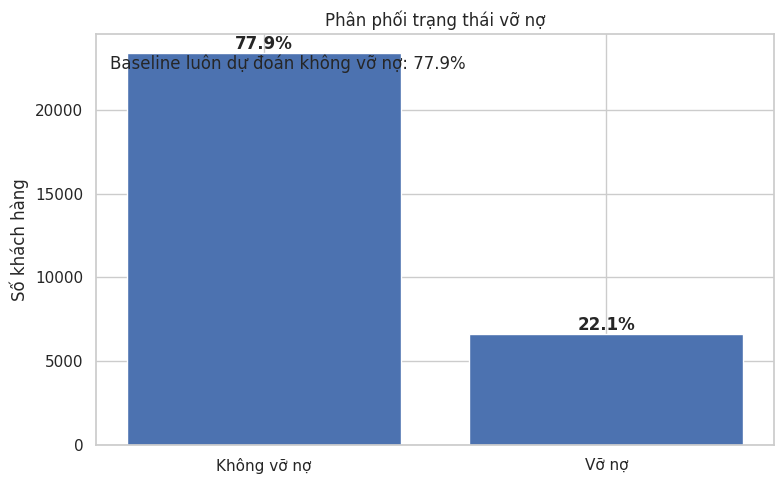

Baseline accuracy: 0.7788


In [29]:

# Phân phối biến mục tiêu và baseline accuracy
plot_target = target_summary.sort_values("DEFAULT")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_target["Nhãn"], plot_target["Số khách hàng"])
ax.set_title("Phân phối trạng thái vỡ nợ")
ax.set_ylabel("Số khách hàng")

for bar, rate in zip(bars, plot_target["Tỷ trọng"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1%}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

baseline_accuracy = float((df["DEFAULT"] == 0).mean())
ax.text(
    0.02,
    0.95,
    f"Baseline luôn dự đoán không vỡ nợ: {baseline_accuracy:.1%}",
    transform=ax.transAxes,
    va="top",
)

plt.tight_layout()
savefig("05_target_distribution.png")
plt.show()

print(f"Baseline accuracy: {baseline_accuracy:.4f}")


,Biến,Nhóm,customers,defaults,default_rate
0,Giới tính,Nam,11888,2873,0.2417
1,Giới tính,Nữ,18112,3763,0.2078
2,Học vấn,Khác/không xác định,468,33,0.0705
3,Học vấn,Sau đại học,10585,2036,0.1923
4,Học vấn,THPT,4917,1237,0.2516
5,Học vấn,Đại học,14030,3330,0.2373
6,Hôn nhân,Khác/không xác định,377,89,0.2361
7,Hôn nhân,Đã kết hôn,13659,3206,0.2347
8,Hôn nhân,Độc thân,15964,3341,0.2093
9,Độ tuổi,21–30,11013,2471,0.2244


Đã lưu bảng: /content/cdnc_outputs/06_demographic_default_rates.csv
Đã lưu hình: /content/cdnc_outputs/06_demographic_default_rates.png


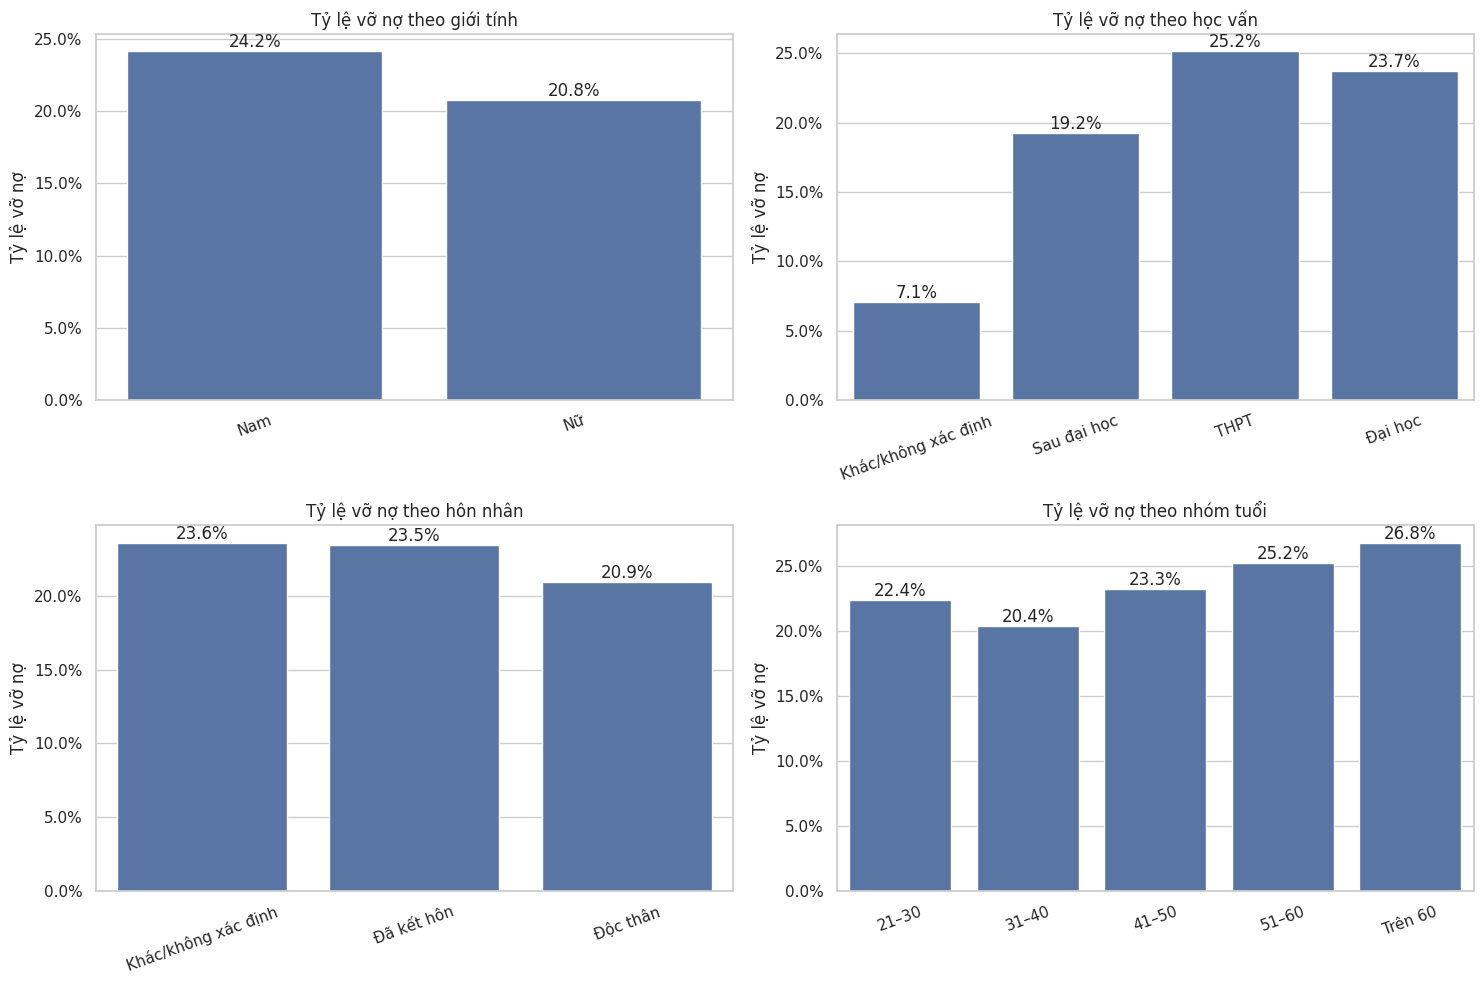

In [30]:

def default_rate_table(data: pd.DataFrame, group_col: str, label: str) -> pd.DataFrame:
    result = (
        data.groupby(group_col, observed=True)
        .agg(
            customers=("DEFAULT", "size"),
            defaults=("DEFAULT", "sum"),
            default_rate=("DEFAULT", "mean"),
        )
        .reset_index()
        .rename(columns={group_col: "Nhóm"})
    )
    result.insert(0, "Biến", label)
    return result

sex_rate = default_rate_table(df, "SEX_GROUP", "Giới tính")
edu_rate = default_rate_table(df, "EDUCATION_GROUP", "Học vấn")
marriage_rate = default_rate_table(df, "MARRIAGE_GROUP", "Hôn nhân")
age_rate = default_rate_table(df, "AGE_BAND", "Độ tuổi")

demographic_rates = pd.concat(
    [sex_rate, edu_rate, marriage_rate, age_rate],
    ignore_index=True,
)
display(demographic_rates)
save_table(demographic_rates, "06_demographic_default_rates.csv")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_specs = [
    (sex_rate, "Tỷ lệ vỡ nợ theo giới tính", axes[0, 0]),
    (edu_rate, "Tỷ lệ vỡ nợ theo học vấn", axes[0, 1]),
    (marriage_rate, "Tỷ lệ vỡ nợ theo hôn nhân", axes[1, 0]),
    (age_rate, "Tỷ lệ vỡ nợ theo nhóm tuổi", axes[1, 1]),
]

for table, title, ax in plot_specs:
    sns.barplot(data=table, x="Nhóm", y="default_rate", ax=ax, color=PRIMARY_COLOR)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Tỷ lệ vỡ nợ")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis="x", rotation=20)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", labels=[f"{v:.1%}" for v in table["default_rate"]])

plt.tight_layout()
savefig("06_demographic_default_rates.png")
plt.show()


,customers,median_limit,median_avg_bill,median_avg_payment,mean_utilization,mean_delinquent_months,share_any_delay,share_delay_2plus,median_bill_trend,Nhóm
0,23364,"150,000.0000","21,466.7500","2,754.0000",0.3517,0.5042,0.2468,0.1926,"1,593.0000",Không vỡ nợ
1,6636,"90,000.0000","19,793.0000","1,612.4167",0.4497,1.9961,0.6483,0.5847,0.0000,Vỡ nợ


Đã lưu bảng: /content/cdnc_outputs/07_behavior_summary_by_default.csv
Đã lưu bảng: /content/cdnc_outputs/08_limit_band_default_rates.csv
Đã lưu bảng: /content/cdnc_outputs/09_delinquent_month_default_rates.csv
Đã lưu hình: /content/cdnc_outputs/07_limit_and_delinquency_analysis.png


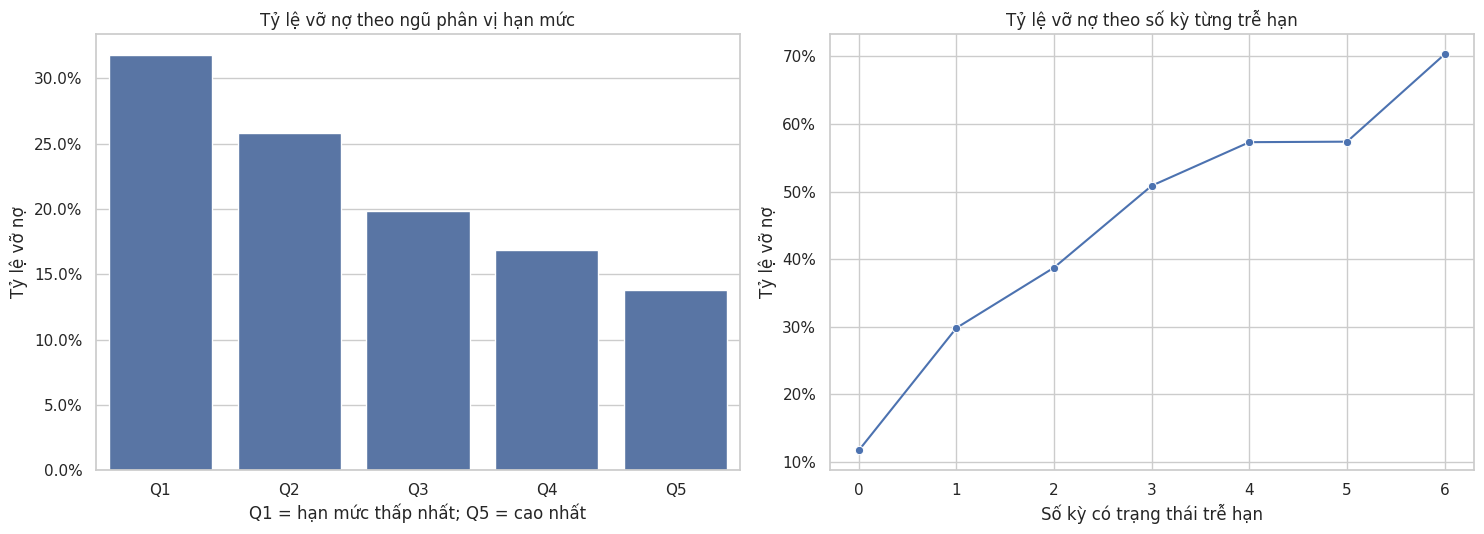

In [31]:

# Tóm tắt hành vi giữa hai nhóm
behavior_summary = (
    df.groupby("DEFAULT")
    .agg(
        customers=("ID", "size"),
        median_limit=("LIMIT_BAL", "median"),
        median_avg_bill=("AVG_BILL_POS", "median"),
        median_avg_payment=("AVG_PAYMENT", "median"),
        mean_utilization=("UTILIZATION_AVG", "mean"),
        mean_delinquent_months=("DELINQUENT_MONTHS", "mean"),
        share_any_delay=("ANY_DELAY", "mean"),
        share_delay_2plus=("DELAY_2PLUS", "mean"),
        median_bill_trend=("BILL_TREND", "median"),
    )
    .reset_index()
)
behavior_summary["Nhóm"] = behavior_summary["DEFAULT"].map(
    {0: "Không vỡ nợ", 1: "Vỡ nợ"}
)

display(behavior_summary.drop(columns="DEFAULT"))
save_table(behavior_summary, "07_behavior_summary_by_default.csv")

limit_rate = (
    df.groupby("LIMIT_BAND", observed=True)
    .agg(
        customers=("DEFAULT", "size"),
        avg_limit=("LIMIT_BAL", "mean"),
        default_rate=("DEFAULT", "mean"),
    )
    .reset_index()
)
limit_rate["Nhóm hạn mức"] = [f"Q{i}" for i in range(1, len(limit_rate) + 1)]

delay_rate = (
    df.groupby("DELINQUENT_MONTHS", observed=True)
    .agg(
        customers=("DEFAULT", "size"),
        default_rate=("DEFAULT", "mean"),
    )
    .reset_index()
)

save_table(limit_rate, "08_limit_band_default_rates.csv")
save_table(delay_rate, "09_delinquent_month_default_rates.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(data=limit_rate, x="Nhóm hạn mức", y="default_rate", ax=axes[0], color=PRIMARY_COLOR)
axes[0].set_title("Tỷ lệ vỡ nợ theo ngũ phân vị hạn mức")
axes[0].set_xlabel("Q1 = hạn mức thấp nhất; Q5 = cao nhất")
axes[0].set_ylabel("Tỷ lệ vỡ nợ")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))

sns.lineplot(
    data=delay_rate,
    x="DELINQUENT_MONTHS",
    y="default_rate",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Tỷ lệ vỡ nợ theo số kỳ từng trễ hạn")
axes[1].set_xlabel("Số kỳ có trạng thái trễ hạn")
axes[1].set_ylabel("Tỷ lệ vỡ nợ")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
savefig("07_limit_and_delinquency_analysis.png")
plt.show()



### Phân tích ngưỡng rủi ro từ trạng thái thanh toán

Phần này dùng cụm từ **“ngưỡng rủi ro quan sát được”** thay cho “điểm gãy tâm lý”. Biểu đồ chỉ chứng minh mối liên hệ thống kê giữa trễ hạn và vỡ nợ, không đủ để kết luận quan hệ nhân quả hay trạng thái tâm lý của khách hàng.


,Chu kỳ,Status,customers,defaults,default_rate
0,PAY_0,0,23182,3207,0.1383
1,PAY_0,1,3688,1252,0.3395
2,PAY_0,2,2667,1844,0.6914
3,PAY_0,3,322,244,0.7578
4,PAY_0,4,76,52,0.6842
5,PAY_0,5,26,13,0.5000
6,PAY_0,6,11,6,0.5455
7,PAY_0,7,9,7,0.7778
8,PAY_0,8,19,11,0.5789


Đã lưu bảng: /content/cdnc_outputs/10_default_rate_by_pay_status.csv
Đã lưu hình: /content/cdnc_outputs/08_default_rate_by_pay_status.png


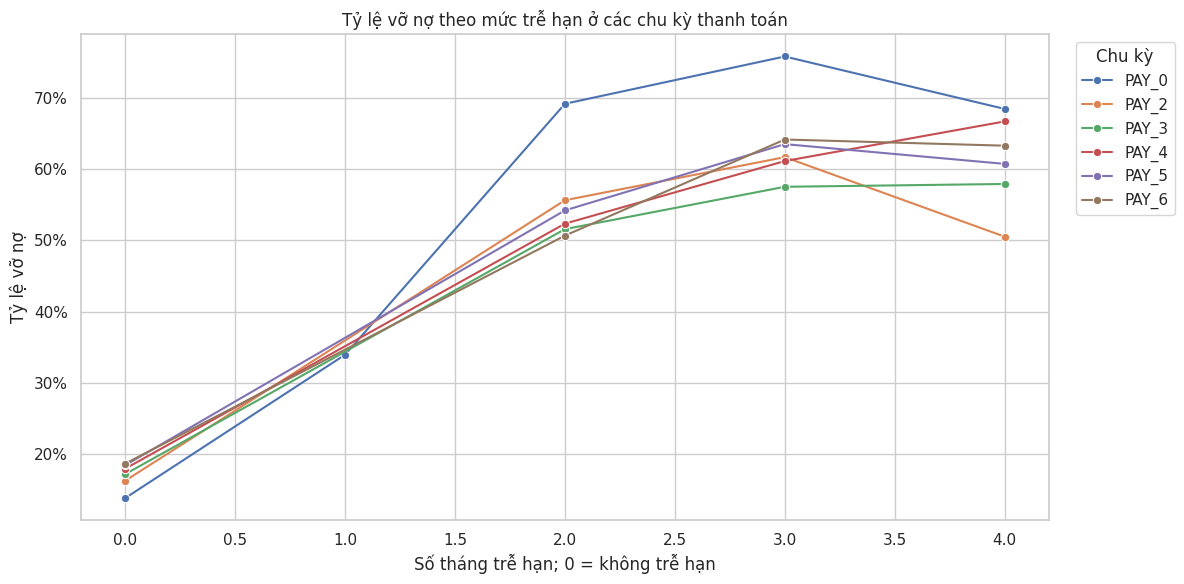

In [32]:

# Chuyển trạng thái âm/0 về nhóm 0 cho biểu đồ rủi ro
pay_long_parts = []
for col in pay_cols:
    temp = df_raw[[col, "DEFAULT"]].copy()
    temp["Status"] = temp[col].clip(lower=0)
    temp["Chu kỳ"] = col
    temp = (
        temp.groupby(["Chu kỳ", "Status"], observed=True)
        .agg(
            customers=("DEFAULT", "size"),
            defaults=("DEFAULT", "sum"),
            default_rate=("DEFAULT", "mean"),
        )
        .reset_index()
    )
    pay_long_parts.append(temp)

pay_default_rates = pd.concat(pay_long_parts, ignore_index=True)
pay_plot = pay_default_rates[
    (pay_default_rates["Status"] <= 4)
    & (pay_default_rates["customers"] >= 30)
].copy()

pay0_table = pay_default_rates[pay_default_rates["Chu kỳ"] == "PAY_0"].copy()
display(pay0_table)
save_table(pay_default_rates, "10_default_rate_by_pay_status.csv")

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=pay_plot,
    x="Status",
    y="default_rate",
    hue="Chu kỳ",
    marker="o",
    ax=ax,
)
ax.set_title("Tỷ lệ vỡ nợ theo mức trễ hạn ở các chu kỳ thanh toán")
ax.set_xlabel("Số tháng trễ hạn; 0 = không trễ hạn")
ax.set_ylabel("Tỷ lệ vỡ nợ")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="Chu kỳ", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
savefig("08_default_rate_by_pay_status.png")
plt.show()



## 4. Mô hình phân loại xác suất vỡ nợ (PD)

Ba nhóm mô hình được so sánh:

- **Dummy Classifier:** đường cơ sở luôn dự đoán lớp phổ biến.
- **Logistic Regression cân bằng lớp:** mô hình tuyến tính, dễ giải thích.
- **Random Forest:** mô hình phi tuyến; gồm cấu hình gần với bài ban đầu và cấu hình có `class_weight='balanced'` để xử lý mất cân bằng lớp.

Dữ liệu được chia 70% huấn luyện và 30% kiểm tra với `stratify` để giữ ổn định tỷ lệ vỡ nợ.


In [11]:

# Các biến đầu vào cho mô hình PD đầy đủ
feature_cols_full = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    *pay_cols,
    *bill_cols,
    *payment_cols,
    "AVG_BILL_POS", "AVG_PAYMENT", "UTILIZATION_AVG",
    "PAYMENT_TO_BILL", "DELINQUENT_MONTHS", "MAX_DELAY", "BILL_TREND",
]

# Thay vô cực bằng NaN rồi điền median để pipeline luôn chạy ổn định
X_full = (
    df[feature_cols_full]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)
X_full = X_full.fillna(X_full.median(numeric_only=True))
y = df["DEFAULT"].astype(int)

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train = X_full.loc[train_idx]
X_test = X_full.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_features = [c for c in feature_cols_full if c not in categorical_features]

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical_features,
        ),
        ("num", StandardScaler(), numeric_features),
    ]
)

models_pd = {
    "Dummy - lớp phổ biến": DummyClassifier(strategy="most_frequent"),
    "Logistic balanced": Pipeline(
        steps=[
            ("preprocess", logistic_preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest gốc": RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Random Forest balanced": RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

pd_results = []
pd_predictions = {}
pd_probabilities = {}

for name, model in models_pd.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    pd_predictions[name] = pred
    pd_probabilities[name] = proba

    pd_results.append(
        {
            "Mô hình": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision lớp vỡ nợ": precision_score(y_test, pred, zero_division=0),
            "Recall lớp vỡ nợ": recall_score(y_test, pred, zero_division=0),
            "F1 lớp vỡ nợ": f1_score(y_test, pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, proba),
            "PR-AUC": average_precision_score(y_test, proba),
        }
    )

pd_results_df = pd.DataFrame(pd_results).sort_values(
    "PR-AUC", ascending=False
).reset_index(drop=True)

display(pd_results_df)
save_table(pd_results_df, "11_pd_model_comparison.csv")

# Chọn Random Forest balanced làm mô hình nghiệp vụ do ưu tiên phát hiện lớp vỡ nợ
selected_pd_name = "Random Forest balanced"
selected_pd_model = models_pd[selected_pd_name]
selected_pd_pred = pd_predictions[selected_pd_name]
selected_pd_proba = pd_probabilities[selected_pd_name]


,Mô hình,Accuracy,Precision lớp vỡ nợ,Recall lớp vỡ nợ,F1 lớp vỡ nợ,ROC-AUC,PR-AUC
0,Random Forest balanced,0.7786,0.4996,0.5927,0.5422,0.7791,0.5528
1,Random Forest gốc,0.8164,0.6607,0.3501,0.4576,0.7770,0.5519
2,Logistic balanced,0.7441,0.4422,0.5997,0.5091,0.7542,0.5194
3,Dummy - lớp phổ biến,0.7788,0.0000,0.0000,0.0000,0.5000,0.2212


Đã lưu bảng: /content/cdnc_outputs/11_pd_model_comparison.csv


In [12]:

# Kiểm tra chéo trên tập huấn luyện cho mô hình Random Forest balanced
cv_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=10,
    min_samples_leaf=8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
        "recall": "recall",
        "f1": "f1",
    },
    n_jobs=1,
)

cv_summary = pd.DataFrame(
    {
        "Chỉ số": ["ROC-AUC", "PR-AUC", "Recall", "F1"],
        "Trung bình": [
            cv_scores["test_roc_auc"].mean(),
            cv_scores["test_pr_auc"].mean(),
            cv_scores["test_recall"].mean(),
            cv_scores["test_f1"].mean(),
        ],
        "Độ lệch chuẩn": [
            cv_scores["test_roc_auc"].std(),
            cv_scores["test_pr_auc"].std(),
            cv_scores["test_recall"].std(),
            cv_scores["test_f1"].std(),
        ],
    }
)

display(cv_summary)
save_table(cv_summary, "12_pd_cross_validation.csv")


,Chỉ số,Trung bình,Độ lệch chuẩn
0,ROC-AUC,0.7832,0.0038
1,PR-AUC,0.5561,0.0081
2,Recall,0.5903,0.0099
3,F1,0.5451,0.0062


Đã lưu bảng: /content/cdnc_outputs/12_pd_cross_validation.csv


Đã lưu hình: /content/cdnc_outputs/09_pd_model_evaluation.png


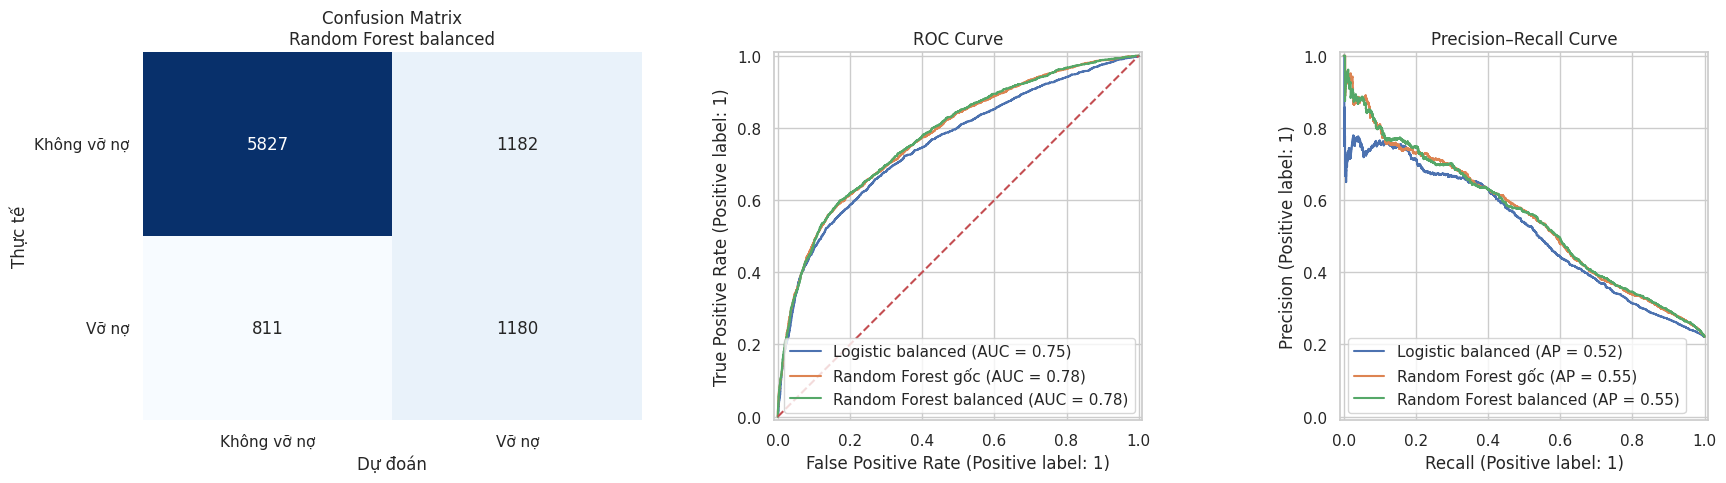

,precision,recall,f1-score,support
Không vỡ nợ,0.8778,0.8314,0.8540,"7,009.0000"
Vỡ nợ,0.4996,0.5927,0.5422,"1,991.0000"
accuracy,0.7786,0.7786,0.7786,0.7786
macro avg,0.6887,0.7120,0.6981,"9,000.0000"
weighted avg,0.7941,0.7786,0.7850,"9,000.0000"


Đã lưu bảng: /content/cdnc_outputs/13_selected_pd_classification_report.csv


In [13]:

# Confusion matrix và đường ROC/Precision-Recall
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, selected_pd_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
)
axes[0].set_title(f"Confusion Matrix\n{selected_pd_name}")
axes[0].set_xlabel("Dự đoán")
axes[0].set_ylabel("Thực tế")
axes[0].set_xticklabels(["Không vỡ nợ", "Vỡ nợ"])
axes[0].set_yticklabels(["Không vỡ nợ", "Vỡ nợ"], rotation=0)

for name in ["Logistic balanced", "Random Forest gốc", "Random Forest balanced"]:
    RocCurveDisplay.from_predictions(
        y_test,
        pd_probabilities[name],
        name=name,
        ax=axes[1],
    )
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("ROC Curve")

for name in ["Logistic balanced", "Random Forest gốc", "Random Forest balanced"]:
    PrecisionRecallDisplay.from_predictions(
        y_test,
        pd_probabilities[name],
        name=name,
        ax=axes[2],
    )
axes[2].set_title("Precision–Recall Curve")

plt.tight_layout()
savefig("09_pd_model_evaluation.png")
plt.show()

selected_report = pd.DataFrame(
    classification_report(
        y_test,
        selected_pd_pred,
        target_names=["Không vỡ nợ", "Vỡ nợ"],
        output_dict=True,
        zero_division=0,
    )
).T

display(selected_report)
save_table(selected_report.reset_index(), "13_selected_pd_classification_report.csv")


,Threshold,Precision,Recall,F1,Số cảnh báo
0,0.2000,0.2590,0.9628,0.4082,7401
1,0.2500,0.2867,0.9121,0.4362,6335
2,0.3000,0.3231,0.8478,0.4679,5224
3,0.3500,0.3625,0.7584,0.4906,4165
4,0.4000,0.4082,0.6816,0.5106,3324
5,0.4500,0.4511,0.6303,0.5259,2782
6,0.5000,0.4996,0.5927,0.5422,2362
7,0.5500,0.5415,0.5439,0.5427,2000
8,0.6000,0.5667,0.5033,0.5331,1768
9,0.6500,0.5917,0.4490,0.5106,1511


Đã lưu bảng: /content/cdnc_outputs/14_threshold_sensitivity.csv
Đã lưu hình: /content/cdnc_outputs/10_threshold_sensitivity.png


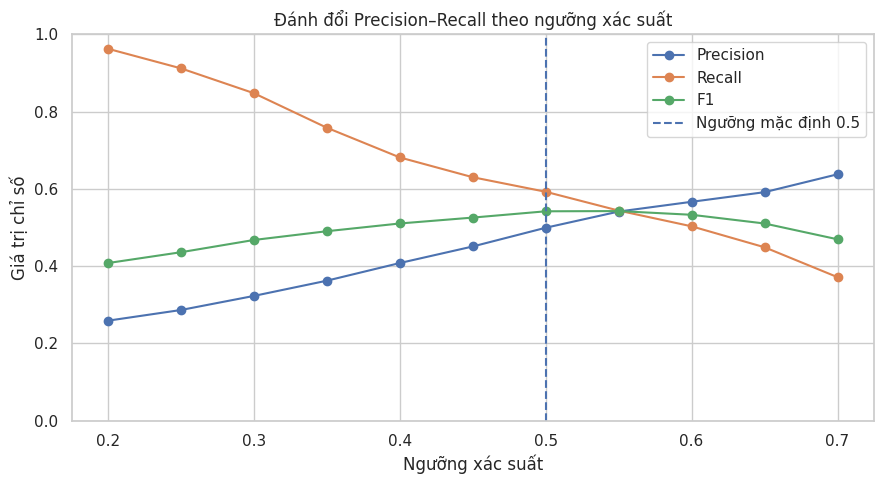

In [14]:

# Phân tích độ nhạy theo ngưỡng xác suất
threshold_rows = []
for threshold in np.arange(0.20, 0.71, 0.05):
    pred_threshold = (selected_pd_proba >= threshold).astype(int)
    threshold_rows.append(
        {
            "Threshold": threshold,
            "Precision": precision_score(y_test, pred_threshold, zero_division=0),
            "Recall": recall_score(y_test, pred_threshold, zero_division=0),
            "F1": f1_score(y_test, pred_threshold, zero_division=0),
            "Số cảnh báo": int(pred_threshold.sum()),
        }
    )

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)
save_table(threshold_table, "14_threshold_sensitivity.csv")

fig, ax = plt.subplots(figsize=(9, 5))
for metric in ["Precision", "Recall", "F1"]:
    ax.plot(
        threshold_table["Threshold"],
        threshold_table[metric],
        marker="o",
        label=metric,
    )
ax.axvline(0.5, linestyle="--", label="Ngưỡng mặc định 0.5")
ax.set_title("Đánh đổi Precision–Recall theo ngưỡng xác suất")
ax.set_xlabel("Ngưỡng xác suất")
ax.set_ylabel("Giá trị chỉ số")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
savefig("10_threshold_sensitivity.png")
plt.show()


,Feature,Gini importance
5,PAY_0,0.1283
28,MAX_DELAY,0.1229
27,DELINQUENT_MONTHS,0.1163
6,PAY_2,0.0597
25,UTILIZATION_AVG,0.0383
7,PAY_3,0.0368
24,AVG_PAYMENT,0.0363
0,LIMIT_BAL,0.0331
26,PAYMENT_TO_BILL,0.0311
11,BILL_AMT1,0.0284


,Feature,Permutation importance,Độ lệch chuẩn
5,PAY_0,0.0722,0.0167
28,MAX_DELAY,0.0296,0.0110
27,DELINQUENT_MONTHS,0.0283,0.0137
26,PAYMENT_TO_BILL,0.0174,0.0011
25,UTILIZATION_AVG,0.0102,0.0028
24,AVG_PAYMENT,0.0084,0.0059
6,PAY_2,0.0068,0.0029
0,LIMIT_BAL,0.0063,0.0030
23,AVG_BILL_POS,0.0054,0.0019
29,BILL_TREND,0.0043,0.0074


Đã lưu bảng: /content/cdnc_outputs/15_pd_gini_importance.csv
Đã lưu bảng: /content/cdnc_outputs/16_pd_permutation_importance.csv
Đã lưu hình: /content/cdnc_outputs/11_pd_feature_importance.png


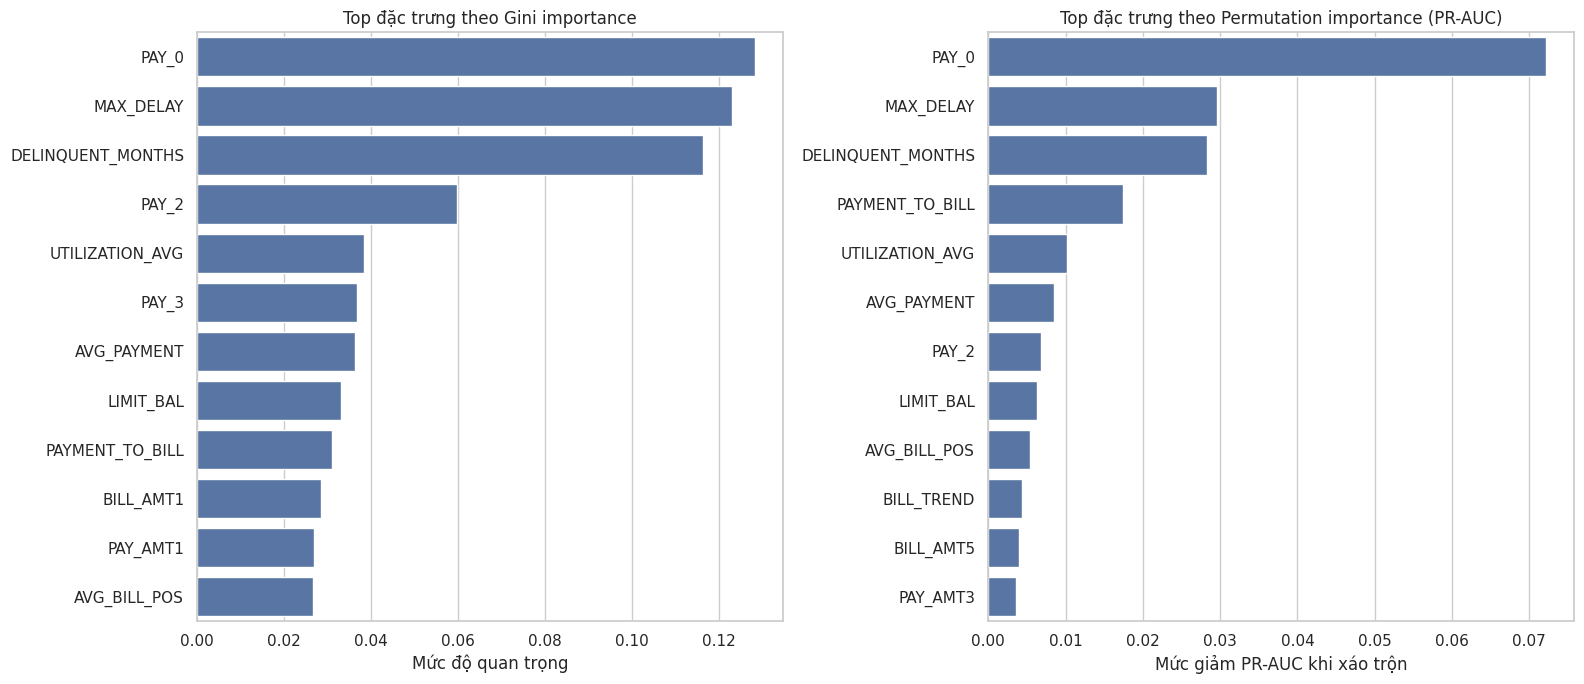

In [15]:

# Feature importance và permutation importance cho mô hình PD đã chọn
rf_importance = pd.DataFrame(
    {
        "Feature": feature_cols_full,
        "Gini importance": selected_pd_model.feature_importances_,
    }
).sort_values("Gini importance", ascending=False)

sample_size = min(1500, len(X_test))
perm_idx = X_test.sample(sample_size, random_state=RANDOM_STATE).index
perm_result = permutation_importance(
    selected_pd_model,
    X_test.loc[perm_idx],
    y_test.loc[perm_idx],
    n_repeats=3,
    random_state=RANDOM_STATE,
    scoring="average_precision",
    n_jobs=1,
)

perm_importance = pd.DataFrame(
    {
        "Feature": feature_cols_full,
        "Permutation importance": perm_result.importances_mean,
        "Độ lệch chuẩn": perm_result.importances_std,
    }
).sort_values("Permutation importance", ascending=False)

display(rf_importance.head(15))
display(perm_importance.head(15))
save_table(rf_importance, "15_pd_gini_importance.csv")
save_table(perm_importance, "16_pd_permutation_importance.csv")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=rf_importance.head(12),
    x="Gini importance",
    y="Feature",
    color=PRIMARY_COLOR,
    ax=axes[0],
)
axes[0].set_title("Top đặc trưng theo Gini importance")
axes[0].set_xlabel("Mức độ quan trọng")
axes[0].set_ylabel("")

sns.barplot(
    data=perm_importance.head(12),
    x="Permutation importance",
    y="Feature",
    color=PRIMARY_COLOR,
    ax=axes[1],
)
axes[1].set_title("Top đặc trưng theo Permutation importance (PR-AUC)")
axes[1].set_xlabel("Mức giảm PR-AUC khi xáo trộn")
axes[1].set_ylabel("")

plt.tight_layout()
savefig("11_pd_feature_importance.png")
plt.show()



## 5. Khung dự báo sớm: PD đồng bộ thời gian, hiệu chỉnh xác suất và EAD proxy

Để tránh target leakage, cả mô hình PD cảnh báo sớm và mô hình EAD proxy chỉ sử dụng dữ liệu từ các kỳ trước `BILL_AMT1`.

Mô hình phân loại cân bằng lớp phù hợp để tăng khả năng phát hiện khách hàng vỡ nợ, nhưng xác suất đầu ra của mô hình này không mặc nhiên là một **PD đã được hiệu chỉnh**. Vì Expected Loss sử dụng trực tiếp xác suất, notebook thực hiện thêm **sigmoid calibration** bằng `CalibratedClassifierCV`.

Hai đầu ra được tách biệt:

- **Mô hình phát hiện rủi ro:** ưu tiên Recall/F1 để nhận diện khách hàng cần cảnh báo.
- **Mô hình xác suất PD:** ưu tiên Brier score, log loss và độ phù hợp giữa PD dự báo với tỷ lệ vỡ nợ thực tế.


,Mô hình,Accuracy,Recall,F1,ROC-AUC,PR-AUC
0,PD đầy đủ đến kỳ gần nhất,0.7786,0.5927,0.5422,0.7791,0.5528
1,PD cảnh báo sớm - chưa calibration,0.7522,0.5419,0.4918,0.7506,0.4976
2,"PD cảnh báo sớm - sigmoid calibrated, threshol...",0.8031,0.2833,0.3890,0.7513,0.4974


Đã lưu bảng: /content/cdnc_outputs/17_full_vs_aligned_pd.csv


,Phiên bản PD,PD trung bình dự báo,Tỷ lệ vỡ nợ thực tế,Brier score,Log loss,ROC-AUC,PR-AUC
0,Chưa calibration,0.4110,0.2212,0.1819,0.5488,0.7506,0.4976
1,Sigmoid calibrated,0.2212,0.2212,0.1442,0.4529,0.7513,0.4974


Đã lưu bảng: /content/cdnc_outputs/18_pd_probability_calibration.csv
Đã lưu hình: /content/cdnc_outputs/12_pd_probability_calibration.png


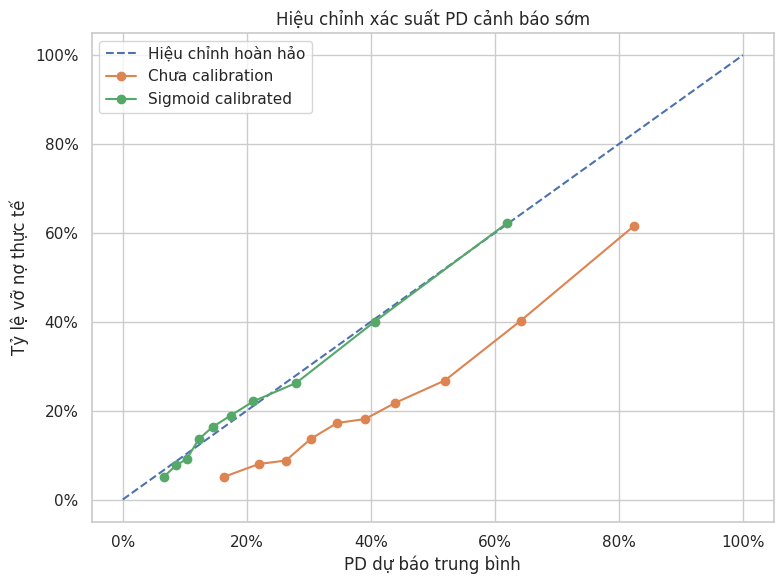

In [16]:

# Tạo bộ đặc trưng chỉ dùng thông tin các kỳ trước BILL_AMT1
past_pay_cols = ["PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
past_bill_cols = [
    "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]
past_payment_cols = [
    "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

forward_df = df.copy()
forward_df["AVG_BILL_PREV"] = forward_df[past_bill_cols].clip(lower=0).mean(axis=1)
forward_df["AVG_PAYMENT_PREV"] = forward_df[past_payment_cols].mean(axis=1)
forward_df["UTILIZATION_PREV"] = (
    forward_df["AVG_BILL_PREV"] / forward_df["LIMIT_BAL"].replace(0, np.nan)
)
forward_df["DELINQUENT_MONTHS_PREV"] = (forward_df[past_pay_cols] > 0).sum(axis=1)
forward_df["MAX_DELAY_PREV"] = forward_df[past_pay_cols].max(axis=1)
forward_df["BILL_TREND_PREV"] = (
    forward_df["BILL_AMT2"] - forward_df["BILL_AMT6"]
)

forward_features = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    *past_pay_cols,
    *past_bill_cols,
    *past_payment_cols,
    "AVG_BILL_PREV", "AVG_PAYMENT_PREV", "UTILIZATION_PREV",
    "DELINQUENT_MONTHS_PREV", "MAX_DELAY_PREV", "BILL_TREND_PREV",
]

X_forward = (
    forward_df[forward_features]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)
X_forward = X_forward.fillna(X_forward.median(numeric_only=True))
Xf_train = X_forward.loc[train_idx]
Xf_test = X_forward.loc[test_idx]

# PD cảnh báo sớm chưa hiệu chỉnh xác suất
aligned_pd_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_leaf=8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
aligned_pd_model.fit(Xf_train, y_train)
aligned_pd_pred = aligned_pd_model.predict(Xf_test)
aligned_pd_proba_raw = aligned_pd_model.predict_proba(Xf_test)[:, 1]

# Hàm tương thích với nhiều phiên bản scikit-learn trên Colab
def make_calibrated_classifier(base_model, method="sigmoid", cv=3):
    try:
        return CalibratedClassifierCV(
            estimator=base_model,
            method=method,
            cv=cv,
            n_jobs=-1,
        )
    except TypeError:
        return CalibratedClassifierCV(
            base_estimator=base_model,
            method=method,
            cv=cv,
            n_jobs=-1,
        )

# Sigmoid calibration được fit hoàn toàn trên tập train qua cross-validation
aligned_pd_calibrated_model = make_calibrated_classifier(
    RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    method="sigmoid",
    cv=3,
)
aligned_pd_calibrated_model.fit(Xf_train, y_train)
aligned_pd_proba_calibrated = aligned_pd_calibrated_model.predict_proba(Xf_test)[:, 1]
aligned_pd_pred_calibrated_05 = (aligned_pd_proba_calibrated >= 0.50).astype(int)

aligned_pd_comparison = pd.DataFrame(
    [
        {
            "Mô hình": "PD đầy đủ đến kỳ gần nhất",
            "Accuracy": accuracy_score(y_test, selected_pd_pred),
            "Recall": recall_score(y_test, selected_pd_pred),
            "F1": f1_score(y_test, selected_pd_pred),
            "ROC-AUC": roc_auc_score(y_test, selected_pd_proba),
            "PR-AUC": average_precision_score(y_test, selected_pd_proba),
        },
        {
            "Mô hình": "PD cảnh báo sớm - chưa calibration",
            "Accuracy": accuracy_score(y_test, aligned_pd_pred),
            "Recall": recall_score(y_test, aligned_pd_pred),
            "F1": f1_score(y_test, aligned_pd_pred),
            "ROC-AUC": roc_auc_score(y_test, aligned_pd_proba_raw),
            "PR-AUC": average_precision_score(y_test, aligned_pd_proba_raw),
        },
        {
            "Mô hình": "PD cảnh báo sớm - sigmoid calibrated, threshold 0.50",
            "Accuracy": accuracy_score(y_test, aligned_pd_pred_calibrated_05),
            "Recall": recall_score(y_test, aligned_pd_pred_calibrated_05),
            "F1": f1_score(y_test, aligned_pd_pred_calibrated_05),
            "ROC-AUC": roc_auc_score(y_test, aligned_pd_proba_calibrated),
            "PR-AUC": average_precision_score(y_test, aligned_pd_proba_calibrated),
        },
    ]
)

display(aligned_pd_comparison)
save_table(aligned_pd_comparison, "17_full_vs_aligned_pd.csv")

# Đánh giá chất lượng xác suất. Brier càng thấp càng tốt.
pd_probability_quality = pd.DataFrame(
    [
        {
            "Phiên bản PD": "Chưa calibration",
            "PD trung bình dự báo": aligned_pd_proba_raw.mean(),
            "Tỷ lệ vỡ nợ thực tế": y_test.mean(),
            "Brier score": brier_score_loss(y_test, aligned_pd_proba_raw),
            "Log loss": log_loss(y_test, aligned_pd_proba_raw),
            "ROC-AUC": roc_auc_score(y_test, aligned_pd_proba_raw),
            "PR-AUC": average_precision_score(y_test, aligned_pd_proba_raw),
        },
        {
            "Phiên bản PD": "Sigmoid calibrated",
            "PD trung bình dự báo": aligned_pd_proba_calibrated.mean(),
            "Tỷ lệ vỡ nợ thực tế": y_test.mean(),
            "Brier score": brier_score_loss(y_test, aligned_pd_proba_calibrated),
            "Log loss": log_loss(y_test, aligned_pd_proba_calibrated),
            "ROC-AUC": roc_auc_score(y_test, aligned_pd_proba_calibrated),
            "PR-AUC": average_precision_score(y_test, aligned_pd_proba_calibrated),
        },
    ]
)

display(pd_probability_quality)
save_table(pd_probability_quality, "18_pd_probability_calibration.csv")

# Calibration curve trước và sau hiệu chỉnh
raw_true, raw_pred = calibration_curve(
    y_test, aligned_pd_proba_raw, n_bins=10, strategy="quantile"
)
cal_true, cal_pred = calibration_curve(
    y_test, aligned_pd_proba_calibrated, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Hiệu chỉnh hoàn hảo")
plt.plot(raw_pred, raw_true, marker="o", label="Chưa calibration")
plt.plot(cal_pred, cal_true, marker="o", label="Sigmoid calibrated")
plt.xlabel("PD dự báo trung bình")
plt.ylabel("Tỷ lệ vỡ nợ thực tế")
plt.title("Hiệu chỉnh xác suất PD cảnh báo sớm")
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
savefig("12_pd_probability_calibration.png")
plt.show()



### Dự báo EAD proxy

Biến mục tiêu được định nghĩa là:

\[
EAD\_PROXY = \max(BILL\_AMT1, 0)
\]

Giá trị âm được đưa về 0 vì mục tiêu của bước này là ước lượng **dư nợ dương có khả năng tạo exposure**, không phải tái tạo toàn bộ giá trị kế toán của sao kê.

Các mô hình được chọn bằng MAE kiểm tra chéo trên tập huấn luyện, sau đó mới đánh giá một lần trên tập test.


In [17]:

# Target EAD proxy
y_ead = df["BILL_AMT1"].clip(lower=0)
y_ead_train = y_ead.loc[train_idx]
y_ead_test = y_ead.loc[test_idx]

reg_models = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Linear Regression": Pipeline(
        steps=[
            ("scale", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=140,
        max_depth=14,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=160,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}

reg_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
reg_results = []
reg_predictions = {}
reg_fitted_models = {}

for name, model in reg_models.items():
    cv_mae = -cross_val_score(
        model,
        Xf_train,
        y_ead_train,
        scoring="neg_mean_absolute_error",
        cv=reg_cv,
        n_jobs=1,
    )

    model.fit(Xf_train, y_ead_train)
    pred = np.maximum(model.predict(Xf_test), 0)

    reg_fitted_models[name] = model
    reg_predictions[name] = pred

    reg_results.append(
        {
            "Mô hình": name,
            "CV MAE trung bình": cv_mae.mean(),
            "CV MAE độ lệch chuẩn": cv_mae.std(),
            "Test MAE": mean_absolute_error(y_ead_test, pred),
            "Test RMSE": np.sqrt(mean_squared_error(y_ead_test, pred)),
            "Test R2": r2_score(y_ead_test, pred),
        }
    )

reg_results_df = pd.DataFrame(reg_results).sort_values(
    "CV MAE trung bình", ascending=True
).reset_index(drop=True)

display(reg_results_df)
save_table(reg_results_df, "18_ead_model_comparison.csv")

selected_reg_name = reg_results_df.iloc[0]["Mô hình"]
selected_reg_model = reg_fitted_models[selected_reg_name]
ead_pred = reg_predictions[selected_reg_name]

print("Mô hình EAD được chọn theo CV MAE:", selected_reg_name)


,Mô hình,CV MAE trung bình,CV MAE độ lệch chuẩn,Test MAE,Test RMSE,Test R2
0,Linear Regression,"8,650.3674",169.9768,"8,659.3912","22,888.8778",0.9034
1,Random Forest Regressor,"8,764.2983",145.0874,"8,721.1450","23,233.6557",0.9004
2,HistGradientBoosting,"8,972.9890",27.7865,"9,001.4127","22,964.5182",0.9027
3,Median baseline,"44,907.9808",321.9477,"44,934.1940","79,164.8766",-0.1560


Đã lưu bảng: /content/cdnc_outputs/18_ead_model_comparison.csv
Mô hình EAD được chọn theo CV MAE: Linear Regression


Đã lưu hình: /content/cdnc_outputs/12_ead_actual_vs_predicted.png


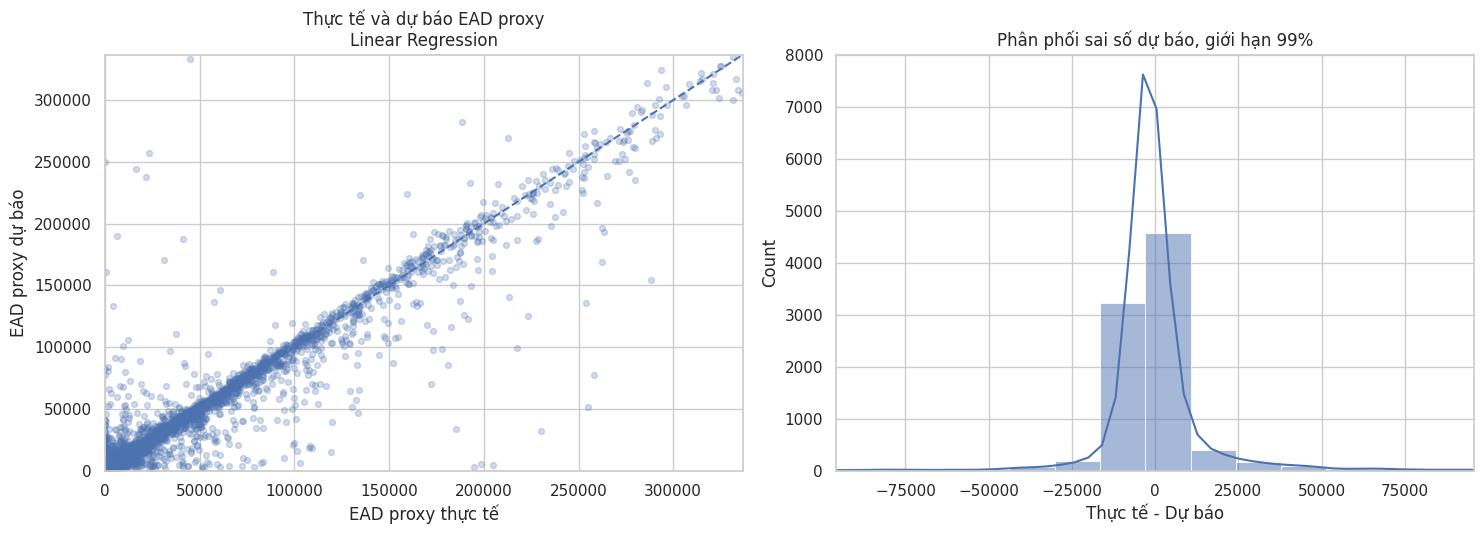

,Feature,Permutation importance,Độ lệch chuẩn
20,AVG_BILL_PREV,"87,922.1412",663.5750
12,BILL_AMT4,"13,242.0671",150.8990
13,BILL_AMT5,"12,810.6434",170.8426
11,BILL_AMT3,"10,728.5528",121.5675
25,BILL_TREND_PREV,"8,461.3740",88.5597
10,BILL_AMT2,"6,172.7626",47.5973
5,PAY_2,702.6687,19.4693
14,BILL_AMT6,608.5398,28.7100
6,PAY_3,221.8047,13.1885
23,DELINQUENT_MONTHS_PREV,180.0820,18.1411


Đã lưu bảng: /content/cdnc_outputs/19_ead_permutation_importance.csv
Đã lưu hình: /content/cdnc_outputs/13_ead_feature_importance.png


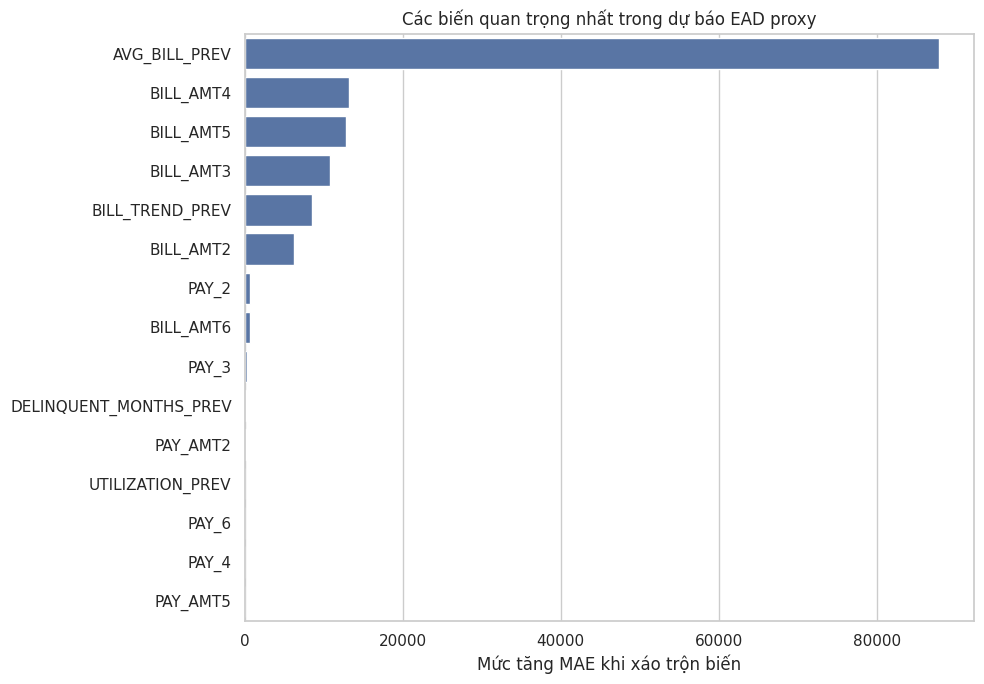

In [18]:

# Đánh giá trực quan mô hình EAD
residuals = y_ead_test.to_numpy() - ead_pred
sample_n = min(4000, len(y_ead_test))
sample_rng = np.random.default_rng(RANDOM_STATE)
sample_pos = sample_rng.choice(len(y_ead_test), size=sample_n, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].scatter(
    y_ead_test.to_numpy()[sample_pos],
    ead_pred[sample_pos],
    alpha=0.25,
    s=18,
)
max_plot = np.quantile(
    np.concatenate([
        y_ead_test.to_numpy()[sample_pos],
        ead_pred[sample_pos],
    ]),
    0.99,
)
axes[0].plot([0, max_plot], [0, max_plot], linestyle="--")
axes[0].set_xlim(0, max_plot)
axes[0].set_ylim(0, max_plot)
axes[0].set_title(f"Thực tế và dự báo EAD proxy\n{selected_reg_name}")
axes[0].set_xlabel("EAD proxy thực tế")
axes[0].set_ylabel("EAD proxy dự báo")

sns.histplot(residuals, bins=60, kde=True, ax=axes[1])
resid_limit = np.quantile(np.abs(residuals), 0.99)
axes[1].set_xlim(-resid_limit, resid_limit)
axes[1].set_title("Phân phối sai số dự báo, giới hạn 99%")
axes[1].set_xlabel("Thực tế - Dự báo")

plt.tight_layout()
savefig("12_ead_actual_vs_predicted.png")
plt.show()

# Permutation importance dùng được cho mọi loại mô hình hồi quy
perm_sample_size = min(1500, len(Xf_test))
perm_reg_idx = Xf_test.sample(
    perm_sample_size,
    random_state=RANDOM_STATE,
).index

reg_perm = permutation_importance(
    selected_reg_model,
    Xf_test.loc[perm_reg_idx],
    y_ead_test.loc[perm_reg_idx],
    n_repeats=3,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
)

reg_perm_df = pd.DataFrame(
    {
        "Feature": forward_features,
        "Permutation importance": reg_perm.importances_mean,
        "Độ lệch chuẩn": reg_perm.importances_std,
    }
).sort_values("Permutation importance", ascending=False)

display(reg_perm_df.head(15))
save_table(reg_perm_df, "19_ead_permutation_importance.csv")

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=reg_perm_df.head(15),
    x="Permutation importance",
    y="Feature",
    ax=ax,
)
ax.set_title("Các biến quan trọng nhất trong dự báo EAD proxy")
ax.set_xlabel("Mức tăng MAE khi xáo trộn biến")
ax.set_ylabel("")

plt.tight_layout()
savefig("13_ead_feature_importance.png")
plt.show()



## 6. Ước lượng Expected Loss và kiểm tra tính hợp lý

Công thức minh họa:

\[
Expected\ Loss_i = PD_i \times EAD_i \times LGD
\]

Trong đó:

- `PD` là xác suất vỡ nợ đã được sigmoid calibration.
- `EAD` là `BILL_AMT1` dự báo từ các kỳ trước và chỉ là proxy.
- `LGD` được giả định theo ba kịch bản 30%, 50% và 70%.

Để tránh báo cáo một con số Expected Loss thiếu kiểm chứng, notebook đối chiếu tổng Expected Loss với một **actual loss proxy**:

\[
Actual\ Loss\ Proxy_i = Default_i \times BILL\_AMT1_i \times LGD
\]

Đây vẫn không phải tổn thất thực tế vì bộ dữ liệu không có số tiền thu hồi hoặc LGD quan sát được.


In [19]:

# Kết hợp PD đã calibration và EAD proxy trên cùng tập test
loss_result = pd.DataFrame(
    {
        "ID": df.loc[test_idx, "ID"].to_numpy(),
        "Actual_Default": y_test.to_numpy(),
        "PD_Raw": aligned_pd_proba_raw,
        "PD_Calibrated": aligned_pd_proba_calibrated,
        "Actual_EAD_Proxy": y_ead_test.to_numpy(),
        "Predicted_EAD_Proxy": ead_pred,
    }
)

lgd_scenarios = {
    "EL_LGD_30": 0.30,
    "EL_LGD_50": 0.50,
    "EL_LGD_70": 0.70,
}

scenario_rows = []

for col, lgd in lgd_scenarios.items():
    loss_result[col] = (
        loss_result["PD_Calibrated"]
        * loss_result["Predicted_EAD_Proxy"]
        * lgd
    )

    actual_col = f"Actual_Loss_Proxy_LGD_{int(lgd * 100)}"
    loss_result[actual_col] = (
        loss_result["Actual_Default"]
        * loss_result["Actual_EAD_Proxy"]
        * lgd
    )

    expected_total = loss_result[col].sum()
    actual_proxy_total = loss_result[actual_col].sum()

    scenario_rows.append(
        {
            "Kịch bản": f"LGD {int(lgd * 100)}%",
            "Tổng Expected Loss": expected_total,
            "Tổng Actual Loss Proxy": actual_proxy_total,
            "Expected / Actual Proxy": (
                expected_total / actual_proxy_total
                if actual_proxy_total > 0
                else np.nan
            ),
            "Expected Loss trung bình/khách hàng": loss_result[col].mean(),
        }
    )

scenario_summary = pd.DataFrame(scenario_rows)

display(scenario_summary)
save_table(scenario_summary, "20_expected_loss_scenarios.csv")

# Chia 4 phân vị theo Expected Loss cơ sở.
# Đây là nhóm EL, không phải nhóm xác suất vỡ nợ thuần túy.
loss_result["EL_Segment"] = pd.qcut(
    loss_result["EL_LGD_50"].rank(method="first"),
    q=4,
    labels=[
        "Q1 - EL thấp",
        "Q2 - EL trung bình",
        "Q3 - EL cao",
        "Q4 - EL rất cao",
    ],
)

el_segment_summary = (
    loss_result.groupby("EL_Segment", observed=True)
    .agg(
        customers=("ID", "size"),
        actual_default_rate=("Actual_Default", "mean"),
        avg_calibrated_pd=("PD_Calibrated", "mean"),
        avg_predicted_ead=("Predicted_EAD_Proxy", "mean"),
        total_expected_loss=("EL_LGD_50", "sum"),
        total_actual_loss_proxy=("Actual_Loss_Proxy_LGD_50", "sum"),
    )
    .reset_index()
)

display(el_segment_summary)
save_table(el_segment_summary, "21_el_segment_summary.csv")

# Calibration theo decile của PD đã hiệu chỉnh
loss_result["PD_Decile"] = pd.qcut(
    loss_result["PD_Calibrated"].rank(method="first"),
    q=10,
    labels=[f"D{i}" for i in range(1, 11)],
)

pd_decile_summary = (
    loss_result.groupby("PD_Decile", observed=True)
    .agg(
        customers=("ID", "size"),
        avg_raw_pd=("PD_Raw", "mean"),
        avg_calibrated_pd=("PD_Calibrated", "mean"),
        actual_default_rate=("Actual_Default", "mean"),
        total_expected_loss=("EL_LGD_50", "sum"),
        total_actual_loss_proxy=("Actual_Loss_Proxy_LGD_50", "sum"),
    )
    .reset_index()
)

display(pd_decile_summary)
save_table(pd_decile_summary, "22_pd_decile_calibration.csv")

# Khả năng tập trung đúng các khoản tổn thất ở nhóm ưu tiên cao nhất
loss_sorted = loss_result.sort_values("EL_LGD_50", ascending=False).copy()
capture_rows = []

for population_share in [0.10, 0.20, 0.30, 0.50]:
    n_top = max(1, int(np.ceil(len(loss_sorted) * population_share)))
    top_slice = loss_sorted.head(n_top)

    capture_rows.append(
        {
            "Tỷ lệ khách hàng ưu tiên": population_share,
            "Tỷ trọng Expected Loss": (
                top_slice["EL_LGD_50"].sum()
                / loss_sorted["EL_LGD_50"].sum()
            ),
            "Tỷ trọng Actual Loss Proxy được bao phủ": (
                top_slice["Actual_Loss_Proxy_LGD_50"].sum()
                / loss_sorted["Actual_Loss_Proxy_LGD_50"].sum()
            ),
            "Tỷ trọng khách hàng vỡ nợ được bao phủ": (
                top_slice["Actual_Default"].sum()
                / loss_sorted["Actual_Default"].sum()
            ),
        }
    )

capture_summary = pd.DataFrame(capture_rows)
display(capture_summary)
save_table(capture_summary, "23_el_capture_summary.csv")

top_10_expected_share = capture_summary.loc[
    capture_summary["Tỷ lệ khách hàng ưu tiên"] == 0.10,
    "Tỷ trọng Expected Loss",
].iloc[0]

top_10_actual_loss_capture = capture_summary.loc[
    capture_summary["Tỷ lệ khách hàng ưu tiên"] == 0.10,
    "Tỷ trọng Actual Loss Proxy được bao phủ",
].iloc[0]

base_expected_total = scenario_summary.loc[
    scenario_summary["Kịch bản"] == "LGD 50%",
    "Tổng Expected Loss",
].iloc[0]

base_actual_proxy_total = scenario_summary.loc[
    scenario_summary["Kịch bản"] == "LGD 50%",
    "Tổng Actual Loss Proxy",
].iloc[0]

base_expected_actual_ratio = scenario_summary.loc[
    scenario_summary["Kịch bản"] == "LGD 50%",
    "Expected / Actual Proxy",
].iloc[0]

print(
    f"LGD 50%: Expected Loss bằng {base_expected_actual_ratio:.1%} "
    "Actual Loss Proxy."
)
print(
    f"Top 10% khách hàng theo EL chiếm {top_10_expected_share:.1%} "
    f"Expected Loss và bao phủ {top_10_actual_loss_capture:.1%} "
    "Actual Loss Proxy."
)


,Kịch bản,Tổng Expected Loss,Tổng Actual Loss Proxy,Expected / Actual Proxy,Expected Loss trung bình/khách hàng
0,LGD 30%,"27,698,455.9980","30,028,258.5000",0.9224,"3,077.6062"
1,LGD 50%,"46,164,093.3300","50,047,097.5000",0.9224,"5,129.3437"
2,LGD 70%,"64,629,730.6620","70,065,936.5000",0.9224,"7,181.0812"


Đã lưu bảng: /content/cdnc_outputs/20_expected_loss_scenarios.csv


,EL_Segment,customers,actual_default_rate,avg_calibrated_pd,avg_predicted_ead,total_expected_loss,total_actual_loss_proxy
0,Q1 - EL thấp,2250,0.1747,0.1719,"5,356.1981","793,797.6970","488,039.5000"
1,Q2 - EL trung bình,2250,0.1769,0.1903,"18,039.4047","2,550,441.2849","1,924,398.5000"
2,Q3 - EL cao,2250,0.2147,0.2067,"51,686.3141","7,974,902.2611","8,083,888.5000"
3,Q4 - EL rất cao,2250,0.3187,0.3158,"130,251.9553","34,844,952.0870","39,550,771.0000"


Đã lưu bảng: /content/cdnc_outputs/21_el_segment_summary.csv


,PD_Decile,customers,avg_raw_pd,avg_calibrated_pd,actual_default_rate,total_expected_loss,total_actual_loss_proxy
0,D1,900,0.1642,0.0662,0.0511,"1,919,428.7076","1,999,518.5000"
1,D2,900,0.2204,0.0856,0.0767,"2,630,656.0779","2,577,445.0000"
2,D3,900,0.2635,0.1032,0.0911,"2,800,144.2409","3,176,301.5000"
3,D4,900,0.3037,0.1223,0.1356,"3,229,147.4249","4,343,639.5000"
4,D5,900,0.3457,0.1448,0.1633,"3,946,301.0508","4,573,657.0000"
5,D6,900,0.3906,0.1739,0.1889,"3,702,008.4123","4,481,562.0000"
6,D7,900,0.4393,0.2107,0.2211,"3,597,327.9061","4,454,310.0000"
7,D8,900,0.5180,0.2795,0.2622,"3,773,777.1660","3,723,025.5000"
8,D9,900,0.6410,0.4060,0.4000,"5,927,870.0738","5,658,393.0000"
9,D10,900,0.8236,0.6199,0.6222,"14,637,432.2697","15,059,245.5000"


Đã lưu bảng: /content/cdnc_outputs/22_pd_decile_calibration.csv


,Tỷ lệ khách hàng ưu tiên,Tỷ trọng Expected Loss,Tỷ trọng Actual Loss Proxy được bao phủ,Tỷ trọng khách hàng vỡ nợ được bao phủ
0,0.1000,0.5200,0.5549,0.1899
1,0.2000,0.6959,0.7355,0.3104
2,0.3000,0.8042,0.8405,0.4154
3,0.5000,0.9276,0.9518,0.6027


Đã lưu bảng: /content/cdnc_outputs/23_el_capture_summary.csv
LGD 50%: Expected Loss bằng 92.2% Actual Loss Proxy.
Top 10% khách hàng theo EL chiếm 52.0% Expected Loss và bao phủ 55.5% Actual Loss Proxy.


Đã lưu hình: /content/cdnc_outputs/14_expected_loss_validation.png


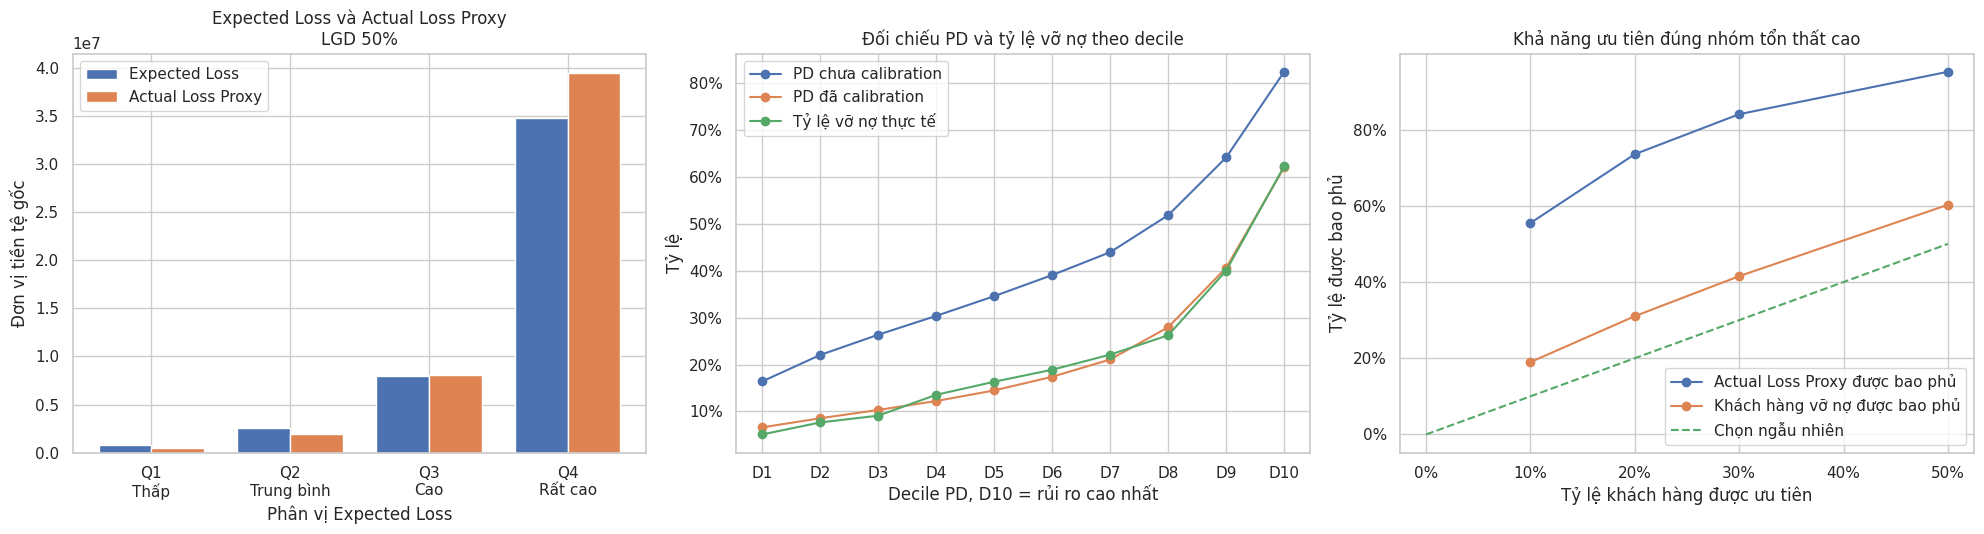

,ID,PD_Calibrated,Predicted_EAD_Proxy,EL_LGD_50,Actual_Default,Actual_EAD_Proxy,Actual_Loss_Proxy_LGD_50
6034,15594,0.5228,"471,419.4151","123,223.3844",1,"458,652.0000","229,326.0000"
5463,27035,0.5033,"438,822.1772","110,424.1323",1,"426,429.0000","213,214.5000"
5019,16520,0.5250,"397,049.5573","104,222.8126",1,"390,188.0000","195,094.0000"
694,14589,0.6298,"317,860.2469","100,094.4988",0,"327,918.0000",0.0000
4819,1497,0.5245,"362,766.6167","95,132.4722",1,"360,023.0000","180,011.5000"
7143,27222,0.6105,"292,278.4947","89,211.0090",1,"285,177.0000","142,588.5000"
1122,215,0.5426,"310,947.5126","84,356.4719",0,"296,573.0000",0.0000
6996,20993,0.5787,"290,551.9321","84,074.8345",1,"282,944.0000","141,472.0000"
4493,19486,0.3672,"445,715.5415","81,843.1012",1,"506,515.0000","253,257.5000"
8974,20968,0.5969,"266,889.0675","79,649.2882",1,"288,585.0000","144,292.5000"


Đã lưu bảng: /content/cdnc_outputs/24_top_20_expected_loss_customers.csv
Đã lưu bảng: /content/cdnc_outputs/25_customer_level_risk_results.csv


In [20]:

# Trực quan hóa Expected Loss, calibration và khả năng tập trung tổn thất
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

segment_order = [
    "Q1 - EL thấp",
    "Q2 - EL trung bình",
    "Q3 - EL cao",
    "Q4 - EL rất cao",
]

segment_plot = el_segment_summary.set_index("EL_Segment").loc[segment_order].reset_index()
x_pos = np.arange(len(segment_plot))
bar_width = 0.38

axes[0].bar(
    x_pos - bar_width / 2,
    segment_plot["total_expected_loss"],
    width=bar_width,
    label="Expected Loss",
)
axes[0].bar(
    x_pos + bar_width / 2,
    segment_plot["total_actual_loss_proxy"],
    width=bar_width,
    label="Actual Loss Proxy",
)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(
    ["Q1\nThấp", "Q2\nTrung bình", "Q3\nCao", "Q4\nRất cao"]
)
axes[0].set_title("Expected Loss và Actual Loss Proxy\nLGD 50%")
axes[0].set_xlabel("Phân vị Expected Loss")
axes[0].set_ylabel("Đơn vị tiền tệ gốc")
axes[0].legend()

axes[1].plot(
    pd_decile_summary["PD_Decile"],
    pd_decile_summary["avg_raw_pd"],
    marker="o",
    label="PD chưa calibration",
)
axes[1].plot(
    pd_decile_summary["PD_Decile"],
    pd_decile_summary["avg_calibrated_pd"],
    marker="o",
    label="PD đã calibration",
)
axes[1].plot(
    pd_decile_summary["PD_Decile"],
    pd_decile_summary["actual_default_rate"],
    marker="o",
    label="Tỷ lệ vỡ nợ thực tế",
)
axes[1].set_title("Đối chiếu PD và tỷ lệ vỡ nợ theo decile")
axes[1].set_xlabel("Decile PD, D10 = rủi ro cao nhất")
axes[1].set_ylabel("Tỷ lệ")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend()

axes[2].plot(
    capture_summary["Tỷ lệ khách hàng ưu tiên"],
    capture_summary["Tỷ trọng Actual Loss Proxy được bao phủ"],
    marker="o",
    label="Actual Loss Proxy được bao phủ",
)
axes[2].plot(
    capture_summary["Tỷ lệ khách hàng ưu tiên"],
    capture_summary["Tỷ trọng khách hàng vỡ nợ được bao phủ"],
    marker="o",
    label="Khách hàng vỡ nợ được bao phủ",
)
axes[2].plot(
    [0, 0.5],
    [0, 0.5],
    linestyle="--",
    label="Chọn ngẫu nhiên",
)
axes[2].set_title("Khả năng ưu tiên đúng nhóm tổn thất cao")
axes[2].set_xlabel("Tỷ lệ khách hàng được ưu tiên")
axes[2].set_ylabel("Tỷ lệ được bao phủ")
axes[2].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[2].legend()

plt.tight_layout()
savefig("14_expected_loss_validation.png")
plt.show()

# Danh sách khách hàng có Expected Loss cao nhất
top_risk_customers = loss_sorted[
    [
        "ID",
        "PD_Calibrated",
        "Predicted_EAD_Proxy",
        "EL_LGD_50",
        "Actual_Default",
        "Actual_EAD_Proxy",
        "Actual_Loss_Proxy_LGD_50",
    ]
].head(20)

display(top_risk_customers)
save_table(top_risk_customers, "24_top_20_expected_loss_customers.csv")
save_table(loss_result, "25_customer_level_risk_results.csv")



## 7. Kết luận và hạn chế cần đưa vào báo cáo

### Nội dung có thể kết luận từ dữ liệu

- Lịch sử trễ hạn gần nhất và số kỳ trễ hạn là nhóm tín hiệu mạnh nhất đối với khả năng vỡ nợ.
- Hạn mức tín dụng thấp có tỷ lệ vỡ nợ cao hơn, nhưng kết quả này chỉ thể hiện quan hệ thống kê.
- Mô hình Random Forest cân bằng lớp cải thiện khả năng phát hiện khách hàng vỡ nợ so với mô hình gốc, đổi lại Accuracy và Precision giảm.
- Xác suất từ mô hình cân bằng lớp cần được calibration trước khi đưa vào công thức Expected Loss.
- EAD proxy có thể được dự báo khá tốt từ lịch sử dư nợ các kỳ trước, nhưng `BILL_AMT1` không phải EAD thực tế tại thời điểm vỡ nợ.
- Expected Loss giúp ưu tiên các khách hàng vừa có xác suất vỡ nợ cao vừa có dư nợ dự kiến lớn.

### Hạn chế bắt buộc nêu rõ

1. Dữ liệu chỉ có sáu kỳ lịch sử và một nhãn vỡ nợ của kỳ tiếp theo.
2. `BILL_AMT1` chỉ là đại diện gần đúng cho exposure, không phải EAD quan sát tại thời điểm default.
3. Không có số tiền thu hồi, tài sản bảo đảm hoặc chi phí xử lý nợ nên LGD 30%/50%/70% chỉ là kịch bản.
4. `Actual Loss Proxy` chỉ dùng để kiểm tra tính hợp lý tương đối, không phải tổn thất thực tế.
5. Feature importance và EDA thể hiện quan hệ dự báo/tương quan, không chứng minh quan hệ nhân quả hoặc cơ chế tâm lý.
6. Đơn vị tiền tệ phải ghi là **đơn vị gốc của bộ dữ liệu**, không được tự quy đổi hoặc gọi là VND.


In [21]:

# Tổng hợp các kết quả chính để copy vào báo cáo
selected_pd_metrics = pd_results_df[
    pd_results_df["Mô hình"] == selected_pd_name
].iloc[0]
selected_reg_metrics = reg_results_df[
    reg_results_df["Mô hình"] == selected_reg_name
].iloc[0]

calibrated_quality = pd_probability_quality[
    pd_probability_quality["Phiên bản PD"] == "Sigmoid calibrated"
].iloc[0]

key_results = pd.DataFrame(
    {
        "Chỉ tiêu": [
            "Số khách hàng",
            "Tỷ lệ vỡ nợ",
            "Baseline accuracy",
            "Mô hình phát hiện PD được chọn",
            "PD Accuracy",
            "PD Recall lớp vỡ nợ",
            "PD F1 lớp vỡ nợ",
            "PD ROC-AUC",
            "PD PR-AUC",
            "Biến PD quan trọng nhất theo permutation",
            "PD cảnh báo sớm trung bình sau calibration",
            "Tỷ lệ vỡ nợ thực tế tập test",
            "PD calibrated Brier score",
            "PD calibrated Log loss",
            "EAD model được chọn",
            "EAD Test MAE",
            "EAD Test RMSE",
            "EAD Test R2",
            "Tổng Expected Loss - LGD 30%",
            "Tổng Expected Loss - LGD 50%",
            "Tổng Expected Loss - LGD 70%",
            "Actual Loss Proxy - LGD 50%",
            "Expected / Actual Loss Proxy - LGD 50%",
            "Top 10%: tỷ trọng Expected Loss",
            "Top 10%: Actual Loss Proxy được bao phủ",
        ],
        "Kết quả": [
            len(df),
            df["DEFAULT"].mean(),
            baseline_accuracy,
            selected_pd_name,
            selected_pd_metrics["Accuracy"],
            selected_pd_metrics["Recall lớp vỡ nợ"],
            selected_pd_metrics["F1 lớp vỡ nợ"],
            selected_pd_metrics["ROC-AUC"],
            selected_pd_metrics["PR-AUC"],
            perm_importance.iloc[0]["Feature"],
            calibrated_quality["PD trung bình dự báo"],
            calibrated_quality["Tỷ lệ vỡ nợ thực tế"],
            calibrated_quality["Brier score"],
            calibrated_quality["Log loss"],
            selected_reg_name,
            selected_reg_metrics["Test MAE"],
            selected_reg_metrics["Test RMSE"],
            selected_reg_metrics["Test R2"],
            scenario_summary.loc[
                scenario_summary["Kịch bản"] == "LGD 30%",
                "Tổng Expected Loss",
            ].iloc[0],
            base_expected_total,
            scenario_summary.loc[
                scenario_summary["Kịch bản"] == "LGD 70%",
                "Tổng Expected Loss",
            ].iloc[0],
            base_actual_proxy_total,
            base_expected_actual_ratio,
            top_10_expected_share,
            top_10_actual_loss_capture,
        ],
    }
)

display(key_results)
save_table(key_results, "00_key_results.csv")

summary_lines = [
    "TÓM TẮT KẾT QUẢ PHÂN TÍCH - PHIÊN BẢN 2",
    "=" * 60,
]
for _, row in key_results.iterrows():
    summary_lines.append(f"- {row['Chỉ tiêu']}: {row['Kết quả']}")
summary_lines.extend(
    [
        "",
        "LƯU Ý:",
        "- Random Forest balanced được dùng cho phát hiện rủi ro.",
        "- PD dùng trong Expected Loss là PD cảnh báo sớm đã sigmoid calibration.",
        "- BILL_AMT1 chỉ là EAD proxy.",
        "- Actual Loss Proxy không phải tổn thất thực tế.",
        "- LGD 30%/50%/70% là kịch bản giả định.",
        "- Đơn vị tiền tệ là đơn vị gốc của dữ liệu, không phải VND.",
    ]
)

summary_text = "\n".join(summary_lines)
summary_path = os.path.join(OUTPUT_DIR, "00_summary_for_report.txt")
with open(summary_path, "w", encoding="utf-8") as file:
    file.write(summary_text)

zip_base = os.path.join(
    os.path.dirname(OUTPUT_DIR),
    "CDNC_ANALYSIS_OUTPUTS_V2",
)
zip_path = shutil.make_archive(zip_base, "zip", OUTPUT_DIR)

print(summary_text)
print("\nĐã tạo file ZIP:", zip_path)


,Chỉ tiêu,Kết quả
0,Số khách hàng,30000
1,Tỷ lệ vỡ nợ,0.2212
2,Baseline accuracy,0.7788
3,Mô hình phát hiện PD được chọn,Random Forest balanced
4,PD Accuracy,0.7786
5,PD Recall lớp vỡ nợ,0.5927
6,PD F1 lớp vỡ nợ,0.5422
7,PD ROC-AUC,0.7791
8,PD PR-AUC,0.5528
9,Biến PD quan trọng nhất theo permutation,PAY_0


Đã lưu bảng: /content/cdnc_outputs/00_key_results.csv
TÓM TẮT KẾT QUẢ PHÂN TÍCH - PHIÊN BẢN 2
- Số khách hàng: 30000
- Tỷ lệ vỡ nợ: 0.2212
- Baseline accuracy: 0.7788
- Mô hình phát hiện PD được chọn: Random Forest balanced
- PD Accuracy: 0.7785555555555556
- PD Recall lớp vỡ nợ: 0.5926670015067805
- PD F1 lớp vỡ nợ: 0.5421548357454629
- PD ROC-AUC: 0.7790532141390429
- PD PR-AUC: 0.5527619553104084
- Biến PD quan trọng nhất theo permutation: PAY_0
- PD cảnh báo sớm trung bình sau calibration: 0.22120141376420072
- Tỷ lệ vỡ nợ thực tế tập test: 0.2212222222222222
- PD calibrated Brier score: 0.14421852610780228
- PD calibrated Log loss: 0.4529224990682927
- EAD model được chọn: Linear Regression
- EAD Test MAE: 8659.391207982379
- EAD Test RMSE: 22888.877784728324
- EAD Test R2: 0.903366564135823
- Tổng Expected Loss - LGD 30%: 27698455.99801175
- Tổng Expected Loss - LGD 50%: 46164093.330019586
- Tổng Expected Loss - LGD 70%: 64629730.66202741
- Actual Loss Proxy - LGD 50%: 50047097.5


### Tải toàn bộ output

Sau khi chạy hết notebook, cell cuối sẽ tạo `CDNC_ANALYSIS_OUTPUTS_V2.zip`. Tải file này về và gửi lại để tiếp tục vòng chỉnh sửa báo cáo.


In [22]:

from google.colab import files

print("File ZIP sẵn sàng tại:", zip_path)
files.download(zip_path)


File ZIP sẵn sàng tại: /content/CDNC_ANALYSIS_OUTPUTS_V2.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>